In [28]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# 1. DATA LOADING AND CLEANING
DATA_PATH = "../../data/processed/final_merged.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (4994, 22)


,country,year,population,gdp,electricity_demand_per_capita,electricity_demand,electricity_generation,energy_per_capita,energy_per_gdp,fossil_share_elec,...,co2,co2_per_capita,co2_per_gdp,co2_per_unit_energy,consumption_co2,consumption_co2_per_capita,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_c,iso_code
0,Afghanistan,2000,20130334.0,1.128379e+10,28.315475,0.57,0.48,262.680481,0.468623,35.416668,...,1.047128,0.052017,0.092799,0.198025,NaN,NaN,0.000505,0.000902,0.998,AFG
1,Afghanistan,2001,20284303.0,1.102127e+10,38.453377,0.78,0.69,179.891907,0.331085,27.536232,...,1.069098,0.052706,0.097003,0.292985,NaN,NaN,0.000506,0.000904,1.292,AFG
2,Afghanistan,2002,21378123.0,1.880487e+10,37.889202,0.81,0.71,155.695435,0.177001,21.126762,...,1.341065,0.062731,0.071315,0.402907,NaN,NaN,0.000509,0.000911,1.399,AFG
3,Afghanistan,2003,22733053.0,2.107434e+10,44.428699,1.01,0.91,174.557922,0.188297,30.769230,...,1.559679,0.068608,0.074008,0.393041,NaN,NaN,0.000512,0.000920,0.593,AFG
4,Afghanistan,2004,23560656.0,2.233257e+10,37.774837,0.89,0.79,157.757523,0.166433,29.113924,...,1.237247,0.052513,0.055401,0.332873,NaN,NaN,0.000515,0.000930,1.437,AFG


In [ ]:
# Select Variables for Analysis
analysis_df = df[
    [
        "country",
        "year",
        "temperature_change_c",
        "electricity_demand_per_capita",
        "co2_per_capita",
        "gdp",
        "population",
        "renewables_share_elec",
    ]
].dropna()

print("Analysis Shape:", analysis_df.shape)

Analysis Shape: (3778, 9)


In [31]:
# Research Questions

print("Research Question 1")
print("How does climate change influence electricity demand across countries between 2001 and 2022?")

print("\nResearch Question 2")
print("What is the relationship between temperature change, CO₂ emissions, and electricity demand per capita?")

print("\nResearch Question 3")
print("Can climate and economic indicators be used to predict future electricity demand patterns?")

Research Question 1
How does climate change influence electricity demand across countries between 2001 and 2022?

Research Question 2
What is the relationship between temperature change, CO₂ emissions, and electricity demand per capita?

Research Question 3
Can climate and economic indicators be used to predict future electricity demand patterns?


In [32]:
# Hypotheses

print("H1: There is a positive relationship between temperature change and electricity demand per capita.")

print("H0: There is no significant relationship between temperature change and electricity demand per capita.")

print("\nH2: Countries with higher CO₂ emissions per capita tend to have higher electricity demand per capita.")

print("\nH3: Renewable energy usage and GDP significantly influence electricity demand patterns across countries.")

H1: There is a positive relationship between temperature change and electricity demand per capita.
H0: There is no significant relationship between temperature change and electricity demand per capita.

H2: Countries with higher CO₂ emissions per capita tend to have higher electricity demand per capita.

H3: Renewable energy usage and GDP significantly influence electricity demand patterns across countries.


In [33]:
# H1: Temperature Change vs Electricity Demand

print("=" * 60)
print("HYPOTHESIS 1 TEST")
print("=" * 60)

r, p = stats.pearsonr(
    analysis_df["temperature_change_c"],
    analysis_df["electricity_demand_per_capita"]
)

print("Pearson Correlation:", round(r,4))
print("P-value:", round(p,6))

if p < 0.05:
    print("Conclusion: Reject H0")
    print("Temperature change significantly affects electricity demand.")
else:
    print("Conclusion: Fail to Reject H0")

HYPOTHESIS 1 TEST
Pearson Correlation: 0.1858
P-value: 0.0
Conclusion: Reject H0
Temperature change significantly affects electricity demand.


In [34]:
# Country-Level H1 Analysis

countries = [
    "India",
    "Canada",
    "Australia",
    "Brazil",
    "Egypt",
    "Spain",
    "Sweden"
]

results = []

for country in countries:

    subset = analysis_df[
        analysis_df["country"] == country
    ]

    if len(subset) >= 10:

        r, p = stats.pearsonr(
            subset["temperature_change_c"],
            subset["electricity_demand_per_capita"]
        )

        results.append({
            "Country": country,
            "Pearson_R": round(r,4),
            "P_Value": round(p,6)
        })

country_results = pd.DataFrame(results)

country_results

,Country,Pearson_R,P_Value
0,India,0.3684,0.083729
1,Canada,-0.2249,0.302256
2,Australia,-0.5499,0.006560
3,Brazil,0.6071,0.002126
4,Egypt,0.5390,0.007957
5,Spain,0.3878,0.028287
6,Sweden,-0.5563,0.000946


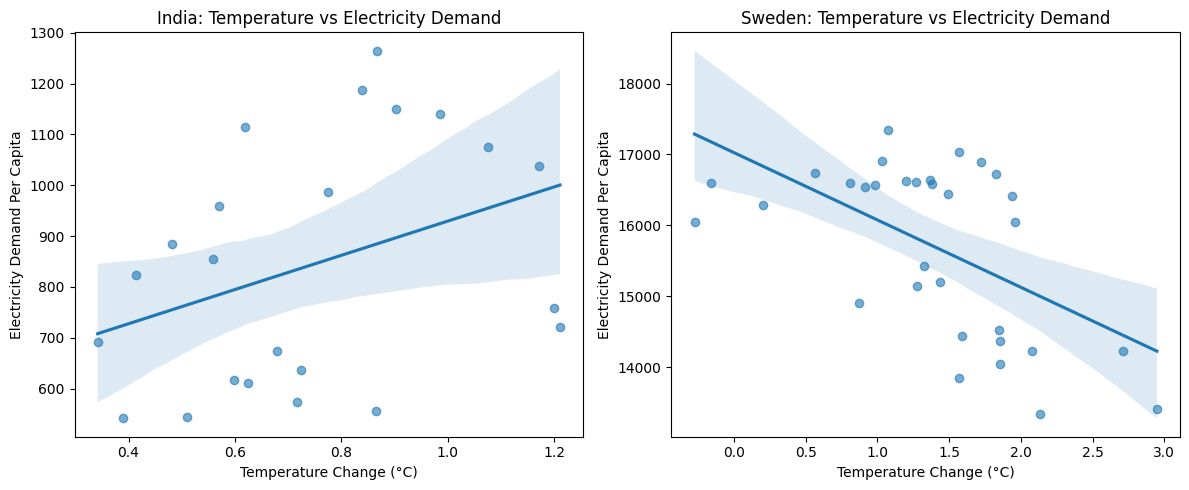

In [ ]:
# ============================================================
# Visual Evidence for H1: Country-Level Temperature-Demand Comparison
# Warm vs Cold Climate Examples
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUTPUT_DIR = Path("../../reports/hypothesis_testing")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

country_compare = analysis_df[
    analysis_df["country"].isin(["India", "Sweden"])
].copy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(
    data=country_compare[country_compare["country"] == "India"],
    x="temperature_change_c",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.6}
)
plt.title("India: Temperature vs Electricity Demand")
plt.xlabel("Temperature Change (°C)")
plt.ylabel("Electricity Demand Per Capita")

plt.subplot(1, 2, 2)
sns.regplot(
    data=country_compare[country_compare["country"] == "Sweden"],
    x="temperature_change_c",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.6}
)
plt.title("Sweden: Temperature vs Electricity Demand")
plt.xlabel("Temperature Change (°C)")
plt.ylabel("Electricity Demand Per Capita")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "04_country_temperature_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [35]:
# H2: CO2 Emissions vs Electricity Demand

print("=" * 60)
print("HYPOTHESIS 2 TEST")
print("=" * 60)

r, p = stats.pearsonr(
    analysis_df["co2_per_capita"],
    analysis_df["electricity_demand_per_capita"]
)

print("Pearson Correlation:", round(r,4))
print("P-value:", round(p,6))

if p < 0.05:
    print("Significant relationship found.")
else:
    print("No significant relationship found.")

HYPOTHESIS 2 TEST
Pearson Correlation: 0.6343
P-value: 0.0
Significant relationship found.


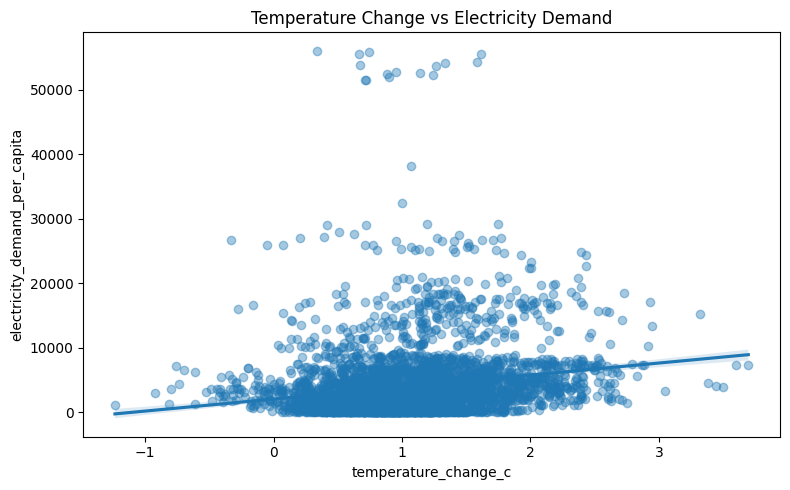

In [ ]:
# # Visual Evidence for H1: Temperature Change vs Electricity Demand

plt.figure(figsize=(8,5))

sns.regplot(
    data=analysis_df,
    x="temperature_change_c",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha":0.4}
)

plt.title("Temperature Change vs Electricity Demand")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_temperature_vs_demand.png", dpi=300, bbox_inches="tight")
plt.show()

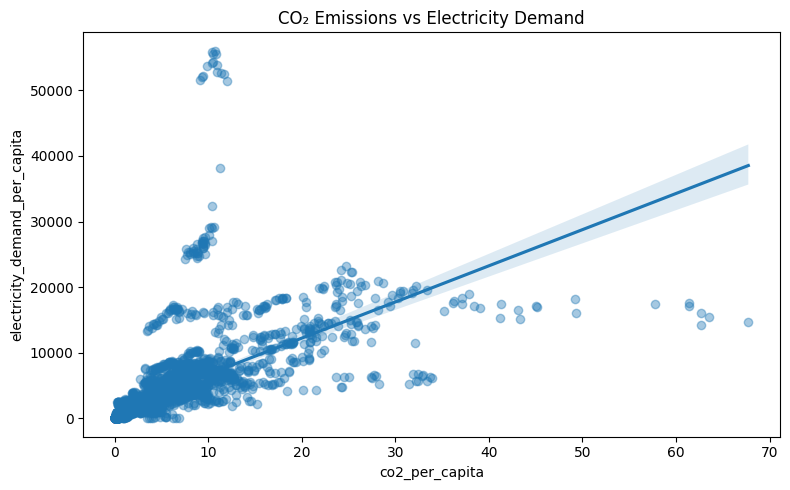

In [ ]:
# Visual Evidence for H2: CO2 Emissions vs Electricity Demand
plt.figure(figsize=(8,5))

sns.regplot(
    data=analysis_df,
    x="co2_per_capita",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha":0.4}
)

plt.title("CO₂ Emissions vs Electricity Demand")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_co2_vs_demand.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
# H3: Multivariate Regression

X = analysis_df[
    [
        "temperature_change_c",
        "co2_per_capita",
        "gdp",
        "renewables_share_elec",
        "population"
    ]
]

y = analysis_df["electricity_demand_per_capita"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     electricity_demand_per_capita   R-squared:                       0.462
Model:                                       OLS   Adj. R-squared:                  0.461
Method:                            Least Squares   F-statistic:                     647.2
Date:                           Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                                   03:21:03   Log-Likelihood:                -36842.
No. Observations:                           3778   AIC:                         7.370e+04
Df Residuals:                               3772   BIC:                         7.373e+04
Df Model:                                      5                                         
Covariance Type:                       nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1221.3574    179.336     -6.810      0.000   -1572.961    -869.753
temperature_change_c    742.4373    121.954      6.088      0.000     503.335     981.540
co2_per_capita          593.4767     11.534     51.455      0.000     570.863     616.090
gdp                    2.972e-10    5.3e-11      5.608      0.000    1.93e-10    4.01e-10
renewables_share_elec    40.0788      2.168     18.487      0.000      35.828      44.329
population            -3.266e-06    6.8e-07     -4.800      0.000    -4.6e-06   -1.93e-06
==============================================================================
Omnibus:                     4089.890   Durbin-Watson:                   0.086
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           451364.310
Skew:                           5.318   Prob(JB):                         0.00
Kurtosis:                      55.480   Cond. No.                     5.98e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.98e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

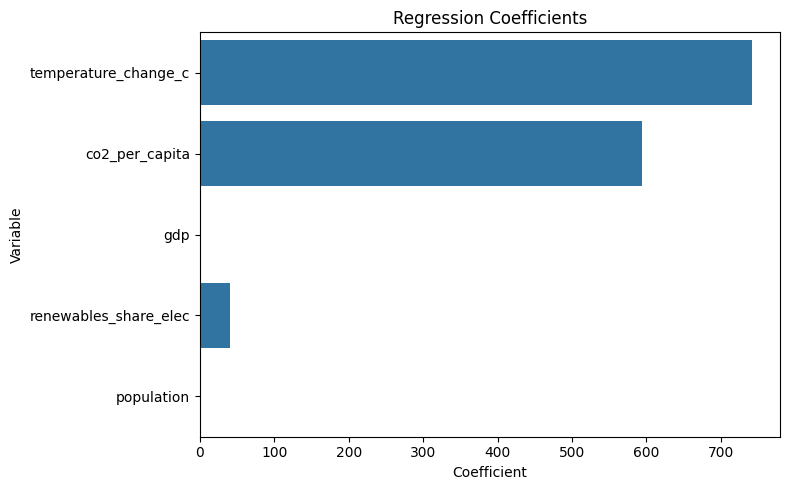

In [ ]:
# Visual Evidence for Coefficient Plot

coef_df = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values
})

coef_df = coef_df[
    coef_df["Variable"] != "const"
]

plt.figure(figsize=(8,5))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Variable"
)

plt.title("Regression Coefficients")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Interpretation of RQ3 Results

print("=" * 60)
print("RQ3 INTERPRETATION")
print("=" * 60)

print("Model R-Squared:", round(model.rsquared,4))

print("\nPredictor Significance:")

for feature, pvalue in model.pvalues.items():

    if pvalue < 0.05:
        print(f"{feature}: Significant (p={pvalue:.6f})")
    else:
        print(f"{feature}: Not Significant (p={pvalue:.6f})")

RQ3 INTERPRETATION
Model R-Squared: 0.4617

Predictor Significance:
const: Significant (p=0.000000)
temperature_change_c: Significant (p=0.000000)
co2_per_capita: Significant (p=0.000000)
gdp: Significant (p=0.000000)
renewables_share_elec: Significant (p=0.000000)
population: Significant (p=0.000002)


In [41]:
# Save Results

OUTPUT_DIR = Path("../../reports/hypothesis_testing")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

country_results.to_csv(
    OUTPUT_DIR / "country_hypothesis_results.csv",
    index=False
)

with open(
    OUTPUT_DIR / "ols_summary.txt",
    "w"
) as f:
    f.write(model.summary().as_text())

print("Results Saved Successfully")

Results Saved Successfully


In [42]:
# Final Summary

print("=" * 70)
print("HYPOTHESIS TESTING COMPLETED SUCCESSFULLY")
print("=" * 70)

print("RQ1 Evaluated")
print("RQ2 Evaluated")
print("RQ3 Evaluated")

print("Country-level Results Saved")
print("Regression Summary Saved")

HYPOTHESIS TESTING COMPLETED SUCCESSFULLY
RQ1 Evaluated
RQ2 Evaluated
RQ3 Evaluated
Country-level Results Saved
Regression Summary Saved
